In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.dates as mdates

# Quick start guide
- How to open the dataset
- Map view
- Station selection and visualization of time series
- time selection and visualization

In [2]:
PANGA = "https://zenodo.org/records/20276956/files/gnss_PANGA_2010_2025.nc?download=1"
SOPAC = "https://zenodo.org/records/20276956/files/gnss_SOPAC_2010_2025.nc?download=1"
UNR = "https://zenodo.org/records/20276956/files/gnss_unr_2010_2025.nc?download=1"

# pip install fsspec requests h5netcdf
ds = xr.open_dataset(
    "simplecache::" + UNR,
    engine="h5netcdf",
    backend_kwargs={"storage_options": {"simplecache": {"cache_storage": "./.cache"}}},
)
ds

<xarray.Dataset> Size: 159MB
Dimensions:        (station: 486, time: 5840)
Coordinates:
  * station        (station) <U4 8kB 'abby' 'abot' 'al2h' ... 'yonc' 'zse1'
    lat            (station) float64 4kB ...
    lon            (station) float64 4kB ...
    elev_m         (station) float64 4kB ...
  * time           (time) datetime64[ns] 47kB 2010-01-01 ... 2025-12-27
Data variables:
    dec_year       (station, time) float64 23MB ...
    east_m         (station, time) float64 23MB ...
    north_m        (station, time) float64 23MB ...
    up_m           (station, time) float64 23MB ...
    east_sigma_m   (station, time) float64 23MB ...
    north_sigma_m  (station, time) float64 23MB ...
    up_sigma_m     (station, time) float64 23MB ...

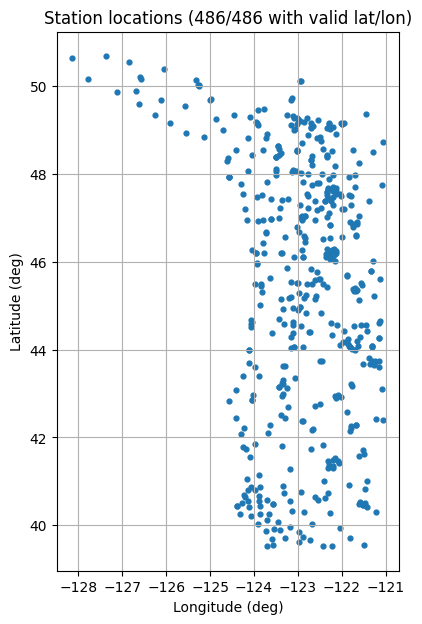

In [3]:
ds_plot = ds.where(ds.lon.notnull() & ds.lat.notnull(), drop=True)

n_total = ds.sizes["station"]
n_ok = ds_plot.sizes["station"]

plt.figure(figsize=(9, 7))
plt.scatter(ds_plot.lon, ds_plot.lat, s=12)
plt.xlabel("Longitude (deg)")
plt.ylabel("Latitude (deg)")
plt.title(f"Station locations ({n_ok}/{n_total} with valid lat/lon)")
plt.grid(True)
plt.gca().set_aspect("equal", adjustable="box")
plt.show()

In [4]:
stat = ds.sel(station="albh")
stat

<xarray.Dataset> Size: 374kB
Dimensions:        (time: 5840)
Coordinates:
  * time           (time) datetime64[ns] 47kB 2010-01-01 ... 2025-12-27
    station        <U4 16B 'albh'
    lat            float64 8B 48.39
    lon            float64 8B -123.5
    elev_m         float64 8B ...
Data variables:
    dec_year       (time) float64 47kB ...
    east_m         (time) float64 47kB ...
    north_m        (time) float64 47kB ...
    up_m           (time) float64 47kB ...
    east_sigma_m   (time) float64 47kB ...
    north_sigma_m  (time) float64 47kB ...
    up_sigma_m     (time) float64 47kB ...

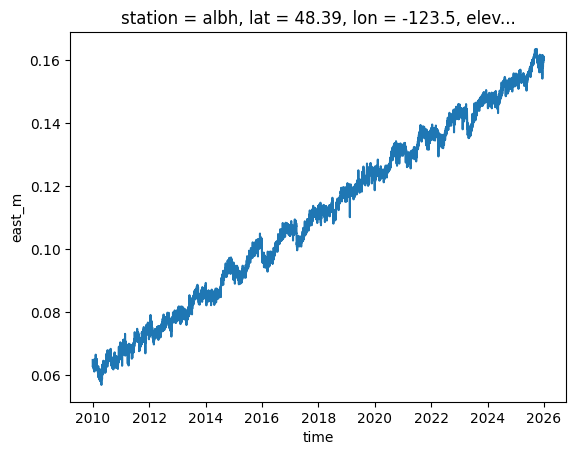

In [5]:
stat.east_m.plot()

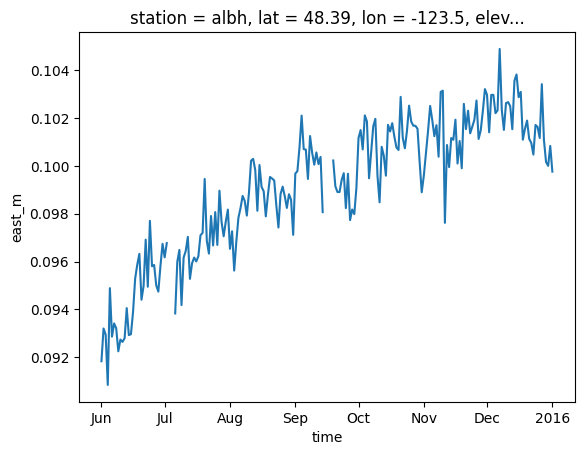

In [6]:
stat.sel(time=slice('2015-06-01', '2016-01-01')).east_m.plot()

# Tremor catalog

In [7]:
TREMOR_URL = "https://zenodo.org/records/20276956/files/tremor_events-2010-2025.csv?download=1"
tremor = pd.read_csv(TREMOR_URL, parse_dates=["starttime"])
tremor

C:\Users\loicb\AppData\Local\Temp\ipykernel_24604\52946325.py:2: DtypeWarning: Columns (0: duration ) have mixed types. Specify dtype option on import or set low_memory=False.
  tremor = pd.read_csv(TREMOR_URL, parse_dates=["starttime"])


,lat,lon,depth,starttime,energy,duration
0,41.100714,-122.717586,20.000000,2017-11-01 21:40:00,33400.346907,300.0
1,41.098432,-122.996891,20.000000,2017-11-01 22:02:30,85501.064423,300.0
2,40.893875,-123.103896,20.000000,2017-11-01 22:17:30,48770.872090,300.0
3,40.948136,-123.123153,44.615385,2017-11-01 22:30:00,40992.256257,300.0
4,41.029690,-122.510571,58.620690,2017-11-01 07:55:00,16823.858153,300.0
...,...,...,...,...,...,...
728563,41.001208,-122.719121,20.000000,2017-11-01 20:20:00,60853.080887,300.0
728564,41.112945,-122.660070,20.000000,2017-11-01 20:40:00,160835.761644,300.0
728565,40.930355,-122.942973,33.076923,2017-11-01 20:42:30,115233.767856,300.0
728566,41.067856,-122.913335,20.000000,2017-11-01 20:45:00,15553.487850,150.0


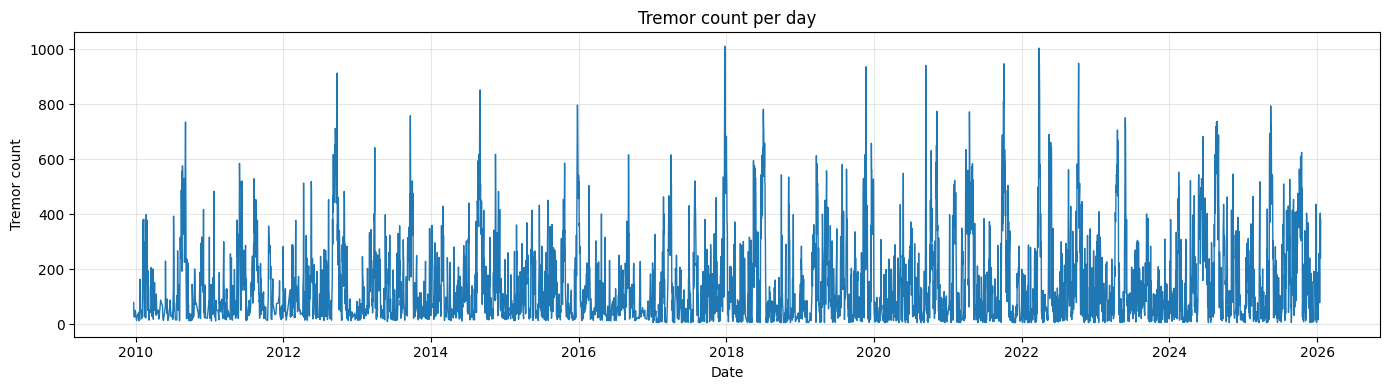

In [8]:
daily_tremor_counts = (
    tremor
    .assign(date=tremor["starttime"].dt.normalize())
    .groupby("date")
    .size()
    .rename("count")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(daily_tremor_counts["date"], daily_tremor_counts["count"], linewidth=1)

ax.set_title("Tremor count per day")
ax.set_xlabel("Date")
ax.set_ylabel("Tremor count")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
start = pd.Timestamp("2017-03-01")
end = pd.Timestamp("2017-04-01")

tremor_mar2017 = tremor[
    (tremor["starttime"] >= start) &
    (tremor["starttime"] < end)
].copy()

print(f"Selected tremor detections: {len(tremor_mar2017):,}")
print(tremor_mar2017["starttime"].min(), "to", tremor_mar2017["starttime"].max())

Selected tremor detections: 5,302
2017-03-01 00:02:30 to 2017-03-31 23:55:00


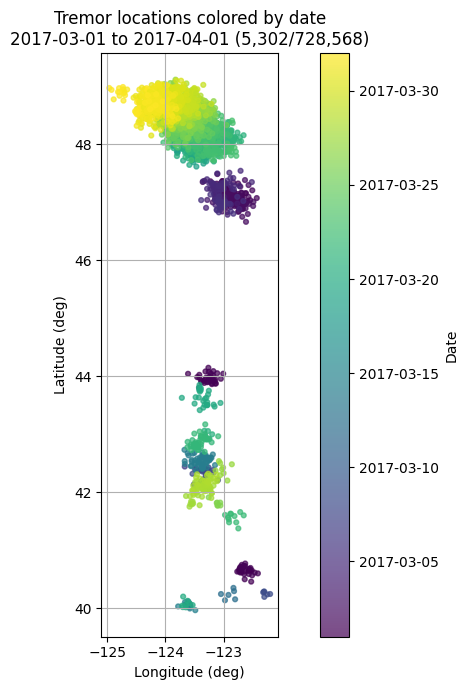

In [10]:
# Convert dates to matplotlib numeric dates for color mapping
tremor_mar2017["date_num"] = mdates.date2num(tremor_mar2017["starttime"])

n_total = len(tremor)
n_ok = len(tremor_mar2017)

plt.figure(figsize=(9, 7))

sc = plt.scatter(
    tremor_mar2017["lon"],
    tremor_mar2017["lat"],
    c=tremor_mar2017["date_num"],
    s=12,
    alpha=0.7,
)

plt.xlabel("Longitude (deg)")
plt.ylabel("Latitude (deg)")
plt.title(
    f"Tremor locations colored by date\n"
    f"{start:%Y-%m-%d} to {end:%Y-%m-%d} ({n_ok:,}/{n_total:,})"
)
plt.grid(True)
plt.gca().set_aspect("equal", adjustable="box")

cbar = plt.colorbar(sc)
cbar.set_label("Date")

# Format colorbar as dates
cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

plt.tight_layout()
plt.show()